In [1]:
import pandas as pd

rfm = pd.read_csv("../data/features/rfm_features.csv")

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


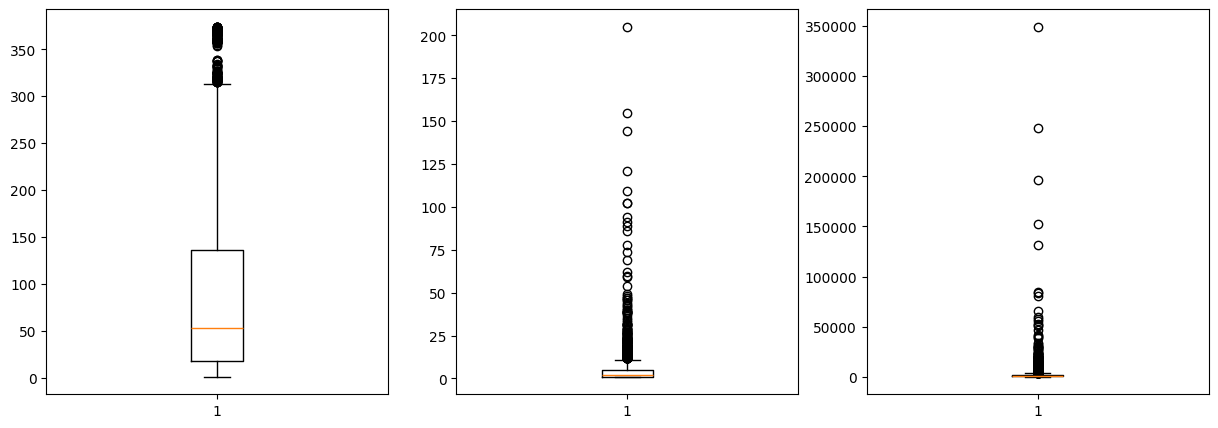

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.boxplot(rfm["Recency"])

plt.subplot(1,3,2)
plt.boxplot(rfm["Frequency"])

plt.subplot(1,3,3)
plt.boxplot(rfm["Monetary"])

plt.show()

In [3]:
import numpy as np

rfm_log = rfm.copy()

rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(
    rfm_log[["Recency","Frequency","Monetary"]]
)

In [5]:
from sklearn.cluster import KMeans

wcss = []

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    wcss.append(model.inertia_)

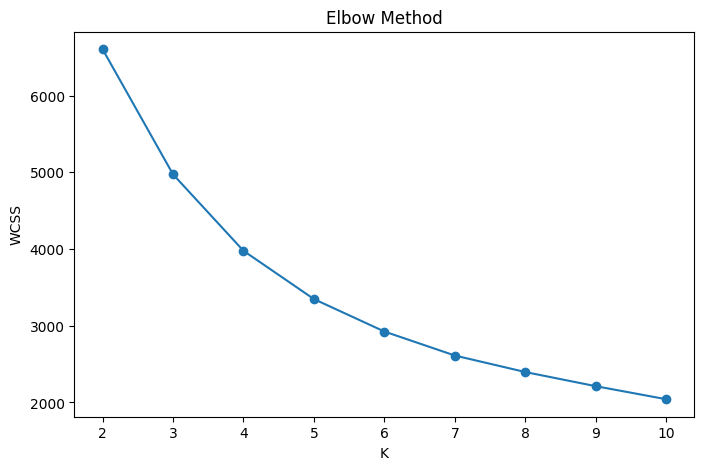

In [6]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), wcss, marker="o")

plt.xlabel("K")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [7]:
from sklearn.metrics import silhouette_score

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    print(k, score)

2 0.42225015406116434
3 0.3283668880526674
4 0.3313764140205813
5 0.3191869557421658
6 0.3118736838108028
7 0.3074805250571932
8 0.2788623664003128
9 0.2762000484515244
10 0.27948786621848704


In [8]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [9]:
cluster_summary = rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean",
    "CustomerID":"count"
}).round(2)

cluster_summary

,Recency,Frequency,Monetary,CustomerID
Cluster,,,,
0,23.95,1.97,532.08,945
1,13.83,13.56,7381.58,778
2,190.57,1.30,305.66,1378
3,80.21,4.14,1759.99,1211


In [10]:
cluster_summary

,Recency,Frequency,Monetary,CustomerID
Cluster,,,,
0,23.95,1.97,532.08,945
1,13.83,13.56,7381.58,778
2,190.57,1.30,305.66,1378
3,80.21,4.14,1759.99,1211


In [11]:
import joblib

joblib.dump(kmeans, "../models/kmeans.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [12]:
rfm.to_csv(
    "../data/features/customer_segments.csv",
    index=False
)

In [13]:
cluster_summary

,Recency,Frequency,Monetary,CustomerID
Cluster,,,,
0,23.95,1.97,532.08,945
1,13.83,13.56,7381.58,778
2,190.57,1.30,305.66,1378
3,80.21,4.14,1759.99,1211


In [21]:
segment_map = {
    0: "New Customers",
    1: "VIP Customers",
    2: "Lost Customers",
    3: "Loyal Customers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_map)

In [22]:
rfm["Segment"]

0       Loyal Customers
1         New Customers
2        Lost Customers
3       Loyal Customers
4         New Customers
             ...       
4307    Loyal Customers
4308     Lost Customers
4309     Lost Customers
4310    Loyal Customers
4311    Loyal Customers
Name: Segment, Length: 4312, dtype: object

In [24]:
rfm.to_csv(
    "../data/features/customer_segments.csv",
    index=False
)

In [25]:
rfm.groupby("Segment").agg({
    "CustomerID":"count",
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean"
}).round(2)

,CustomerID,Recency,Frequency,Monetary
Segment,,,,
Lost Customers,1378,190.57,1.30,305.66
Loyal Customers,1211,80.21,4.14,1759.99
New Customers,945,23.95,1.97,532.08
VIP Customers,778,13.83,13.56,7381.58
